<a href="https://colab.research.google.com/github/Karima-mtq/Basemap/blob/main/projection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!pip install cartopy
import cartopy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.8/11.8 MB 47.0 MB/s eta 0:00:00


In [3]:
!pip install netCDF4
!pip install eofs
!pip install Basemap

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.5/9.5 MB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 21.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 13.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.0/56.0 kB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 19.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 30.5/30.5 MB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.5/46.5 kB 2.9 MB/s eta 0:00:00
  Attempting uninstall: pyshp
    Found existing installation: pyshp 3.0.3
    Uninstalling pyshp-3.0.3:
      Successfully uninstalled pyshp-3.0.3


In [45]:
%matplotlib inline
import xarray as xr
import os
from scipy import signal
from netCDF4 import Dataset
from mpl_toolkits.basemap import Basemap
from eofs.standard import Eof
from netCDF4 import num2date
import numpy as np
import numpy.polynomial.polynomial as poly
import netCDF4 as netcdf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib as mpl
import glob

In [ ]:
grid = xr.open_dataset("/content/grid(5).nc")
print(grid)

<xarray.Dataset> Size: 67MB
Dimensions:  (y: 384, x: 320, nv: 4, pcomp: 86231, qcomp: 87976, ucomp: 88019,
              vcomp: 87567)
Coordinates:
  * pcomp    (pcomp) int32 345kB 641 642 643 849 ... 122511 122512 122513 122514
  * qcomp    (qcomp) int32 352kB 642 643 850 851 ... 122648 122832 122833 122834
  * ucomp    (ucomp) int32 352kB 641 642 643 644 ... 122512 122513 122514 122515
  * vcomp    (vcomp) int32 350kB 641 642 643 849 ... 122831 122832 122833 122834
Dimensions without coordinates: y, x, nv
Data variables: (12/53)
    insw     (y, x) int32 492kB ...
    jnsw     (y, x) int32 492kB ...
    ins      (y, x) int32 492kB ...
    jns      (y, x) int32 492kB ...
    inse     (y, x) int32 492kB ...
    jnse     (y, x) int32 492kB ...
    ...       ...
    vdepth   (y, x) float64 983kB ...
    pmask    (y, x) int32 492kB ...
    umask    (y, x) int32 492kB ...
    vmask    (y, x) int32 492kB ...
    qmask    (y, x) int32 492kB ...
    cplmask  (y, x) int32 492kB ...
Attributes:

In [13]:
# Download all .nc files from the folder
!wget -r -np -nH --cut-dirs=5 -A "*ODA_ens.micom.hm.2006-12.nc" \
    -P /content/drive/MyDrive/ODA_OCN \
    https://ns9039k.web.sigma2.no/datapeak/lgarcia/initializations/ODA/reana/ocn/



--2025-12-28 19:33:27--  https://ns9039k.web.sigma2.no/datapeak/lgarcia/initializations/ODA/reana/ocn/
Resolving ns9039k.web.sigma2.no (ns9039k.web.sigma2.no)... 158.36.102.245
Connecting to ns9039k.web.sigma2.no (ns9039k.web.sigma2.no)|158.36.102.245|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘/content/drive/MyDrive/ODA_OCN/ocn/index.html.tmp’

ocn/index.html.tmp      [  <=>               ]  86.14K   354KB/s    in 0.2s    

2025-12-28 19:33:28 (354 KB/s) - ‘/content/drive/MyDrive/ODA_OCN/ocn/index.html.tmp’ saved [88211]

Loading robots.txt; please ignore errors.
--2025-12-28 19:33:28--  https://ns9039k.web.sigma2.no/robots.txt
Reusing existing connection to ns9039k.web.sigma2.no:443.
HTTP request sent, awaiting response... 404 Not Found
2025-12-28 19:33:28 ERROR 404: Not Found.

Removing /content/drive/MyDrive/ODA_OCN/ocn/index.html.tmp since it should be rejected.

--2025-12-28 19:33:28--  https://ns9039k.web.sigma2.n

In [12]:
all_files = sorted(glob.glob("/content/drive/MyDrive/ODA_OCN/ocn/ODA_ens.micom.hm.*.nc"))
files = [f for f in all_files if int(f.split('.')[-2].replace('-', '')) <= 201012]
# Use netCDF4 engine explicitly
ds_all = xr.open_mfdataset(files, combine="by_coords", engine="netcdf4")
sst = ds_all['sst']
print(sst.shape)

OSError: no files to open

In [7]:
# Extract the time values (cftime objects)
time_vals = ds_all['time'].values

# Get min and max years
year1 = min(t.year for t in time_vals)
year2 = max(t.year for t in time_vals)

print("Year range:", year1, "-", year2)

Year range: 2000 - 2006


In [8]:
sst_data = sst.values
nt,nlat,nlon = sst.shape
startY = year1
endY   = year2
ndy    = year2-year1+1
ny = nt/ndy
print(startY, endY, ndy, ny)

2000 2006 7 11.857142857142858


In [ ]:
import numpy as np
import numpy.polynomial.polynomial as poly

# Dimensions
nt, nlat, nlon = sst_data.shape

sst_detrend = np.empty(sst_data.shape)
sst_coeffs  = np.empty((2, nlat, nlon))
sst_detrend[:,:,:] = np.nan

x = np.linspace(1, nt, nt)

for i in range(nlat):
    for j in range(nlon):
        y = sst_data[:, i, j]   # <-- use raw numpy array
        if np.all(np.isnan(y)):
            continue
        b = ~np.isnan(y)
        coefs = poly.polyfit(x[b], y[b], 1)
        sst_coeffs[0, i, j] = coefs[0]
        sst_coeffs[1, i, j] = coefs[1]
        ffit = poly.polyval(x[b], coefs)
        sst_detrend[b, i, j] = y[b] - ffit

In [ ]:
sst_all = sst_detrend.reshape((ndy,int(ny),nlat,nlon), order='F').transpose((1,0,2,3)) # year, 36, lat, lon
sst_season = np.mean(sst_all, axis=0)
sst_diff = sst_all - sst_season
#mask_4d = np.broadcast_to((pmask_trimmed==0), sst_all.shape)
#sst_diff = np.ma.masked_array(sst_diff, mask=mask_4d) # have to do this, or fill in zeros in sst_diff.
sst_final = sst_diff.transpose((1,0,2,3)).reshape((ndy*int(ny),nlat,nlon), order='F')

In [ ]:
lat = np.linspace(-90, 90, nlat)  # if first row is South
lon = np.linspace(-180, 180, nlon)

In [ ]:
lat = np.linspace(-90, 90, nlat)  # if first row is South
lon = np.linspace(-180, 180, nlon)
coslat = np.cos(np.deg2rad(lat))
wgts = np.sqrt(coslat)[..., np.newaxis]
solver = Eof(sst_final, weights=wgts)

print(coslat.shape)
print(wgts.shape)
eof1 = solver.eofs(neofs=10)
pc1  = solver.pcs(npcs=10, pcscaling=0)
varfrac = solver.varianceFraction()
lambdas = solver.eigenvalues()

(384,)
(384, 1)


In [ ]:
eof1 = solver.eofs(neofs=10)
pc1  = solver.pcs(npcs=10, pcscaling=0)
varfrac = solver.varianceFraction()
lambdas = solver.eigenvalues()

In [ ]:
import xarray as xr
from google.colab import drive

# Monter Drive
drive.mount('/content/drive')

# Créer Dataset
ds = xr.Dataset(
    {
        "EOFs": (("mode","y","x"), eof1),
        "PCs": (("time","mode"), pc1)
    },
    coords={
        "mode": np.arange(1, eof1.shape[0]+1),
        "y": np.arange(eof1.shape[1]),
        "x": np.arange(eof1.shape[2]),
        "time": np.arange(pc1.shape[0])
    }
)

# Chemin pour Drive
save_path = "/content/drive/MyDrive/EOFs_PCs.nc"

# Sauvegarder
ds.to_netcdf(save_path)

print(f"Fichier NetCDF sauvegardé dans : {save_path}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Fichier NetCDF sauvegardé dans : /content/drive/MyDrive/EOFs_PCs.nc


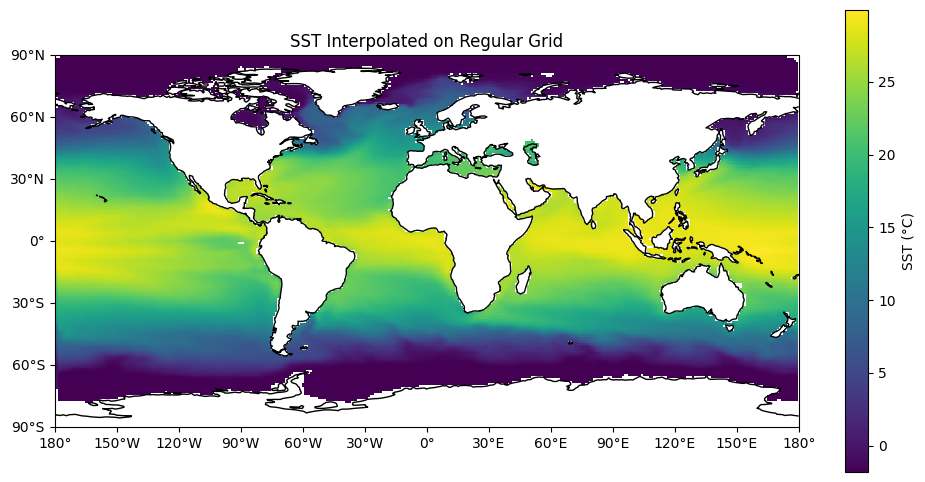

In [ ]:
import xarray as xr
import numpy as np
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Charger SST + mask
ds_sst = xr.open_dataset("/content/drive/MyDrive/ODA_OCN/ocn/ODA_ens.micom.hm.2006-06.nc")
sst = ds_sst["sst"].isel(time=0)

grid = xr.open_dataset("/content/grid(5).nc")
pmask = grid["pmask"]

sst_masked = sst.where(pmask==1)

# Lon/Lat centres
lon = grid["plon"].values
lat = grid["plat"].values

# Grille régulière 1° x 1°
lon_out = np.arange(-180, 181, 1)
lat_out = np.arange(-90, 91, 1)
lon_out_grid, lat_out_grid = np.meshgrid(lon_out, lat_out)

# Interpolation bilinéaire
points = np.column_stack((lon.flatten(), lat.flatten()))
values = sst_masked.values.flatten()
sst_reg = griddata(points, values, (lon_out_grid, lat_out_grid), method='linear')

fig = plt.figure(figsize=(12,6))
ax = plt.axes(projection=ccrs.PlateCarree())

# pcolormesh
im = ax.pcolormesh(lon_out_grid, lat_out_grid, sst_reg,
                   shading="auto", cmap="viridis", transform=ccrs.PlateCarree())

# Continents et côtes
ax.add_feature(cfeature.LAND, facecolor="white")
ax.add_feature(cfeature.COASTLINE)

# Graduations de longitude/latitude
ax.set_xticks(np.arange(-180, 181, 30), crs=ccrs.PlateCarree())
ax.set_yticks(np.arange(-90, 91, 30), crs=ccrs.PlateCarree())
lon_formatter = ccrs.cartopy.mpl.ticker.LongitudeFormatter()
lat_formatter = ccrs.cartopy.mpl.ticker.LatitudeFormatter()
ax.xaxis.set_major_formatter(lon_formatter)
ax.yaxis.set_major_formatter(lat_formatter)

ax.set_global()
plt.colorbar(im, ax=ax, label="SST (°C)")
plt.title("SST Interpolated on Regular Grid")
plt.show()


In [ ]:
import xarray as xr

# Ouvrir le fichier
ds = xr.open_dataset("/content/drive/MyDrive/EOFs_PCs.nc")

# Lire les EOF
eof1 = ds["EOFs"].values      # ou ds["eof1"] selon ton nom de variable
pc1  = ds["PCs"].values       # si tu veux aussi les PCs
varfrac = ds["variance_fraction"].values if "variance_fraction" in ds else None
lambdas = ds["eigenvalues"].values if "eigenvalues" in ds else None

print("EOFs shape :", eof1.shape)
print("PCs shape  :", pc1.shape)


EOFs shape : (10, 384, 320)
PCs shape  : (372, 10)


Plotting EOF 1...


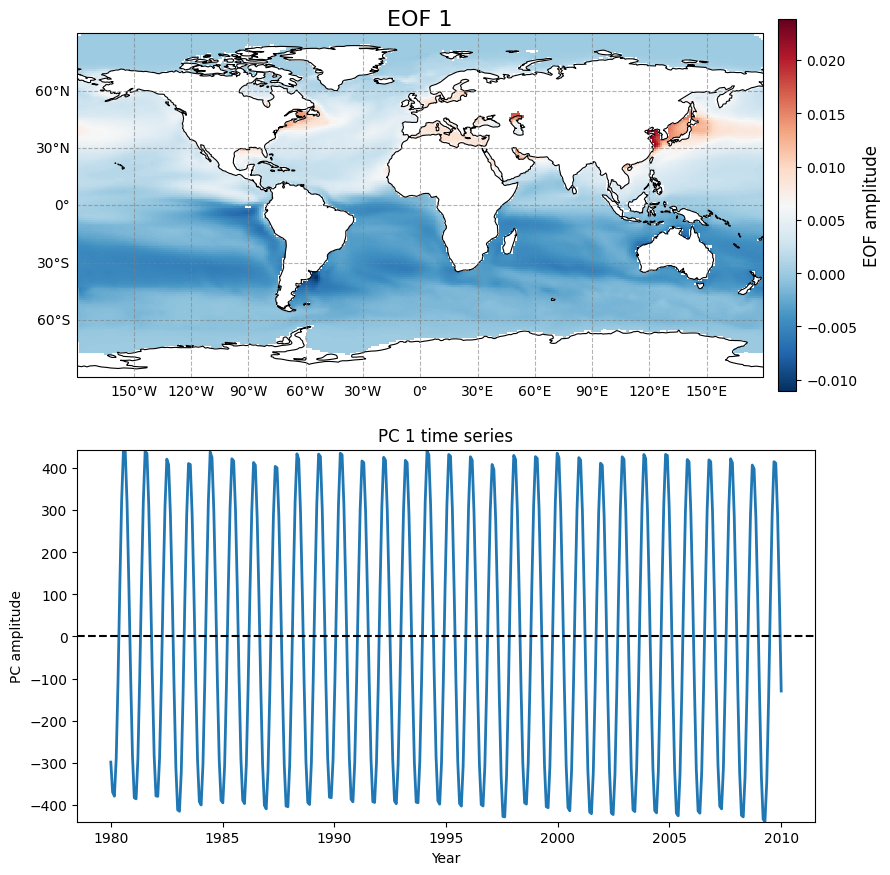

Plotting EOF 2...


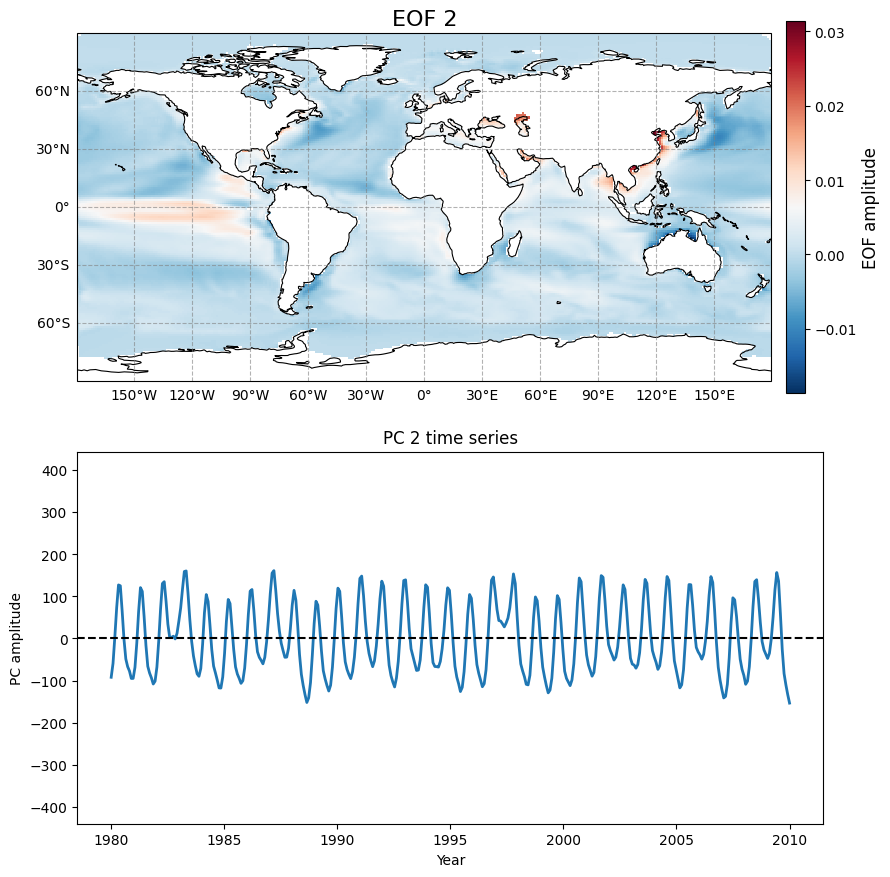

Plotting EOF 3...


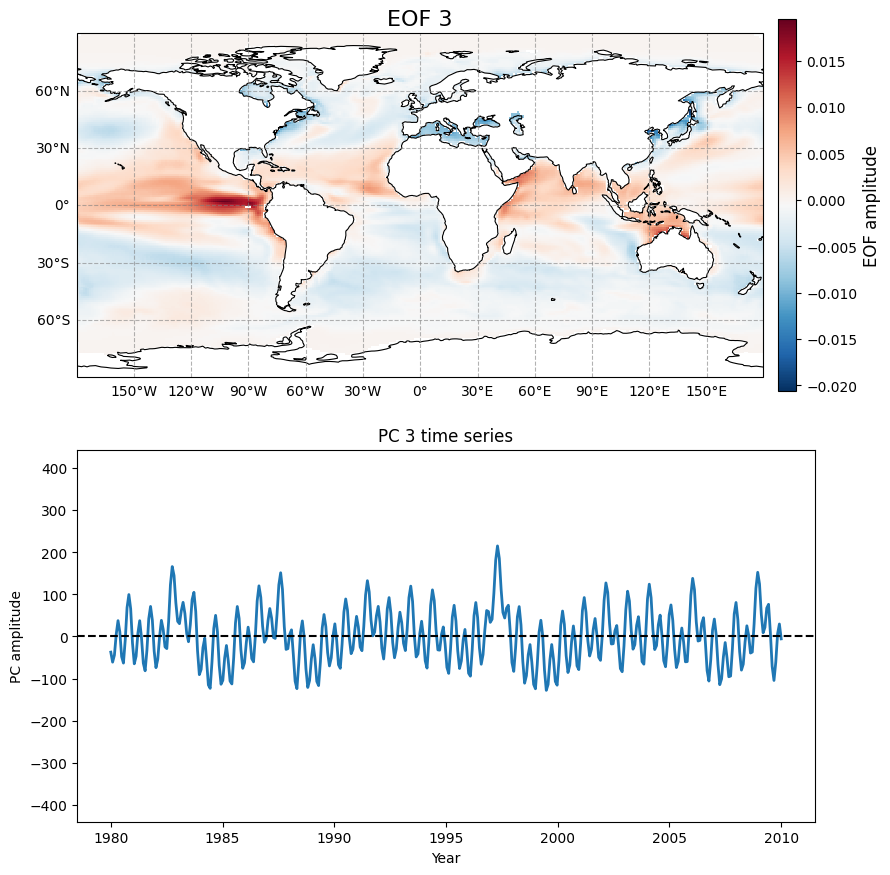

Plotting EOF 4...


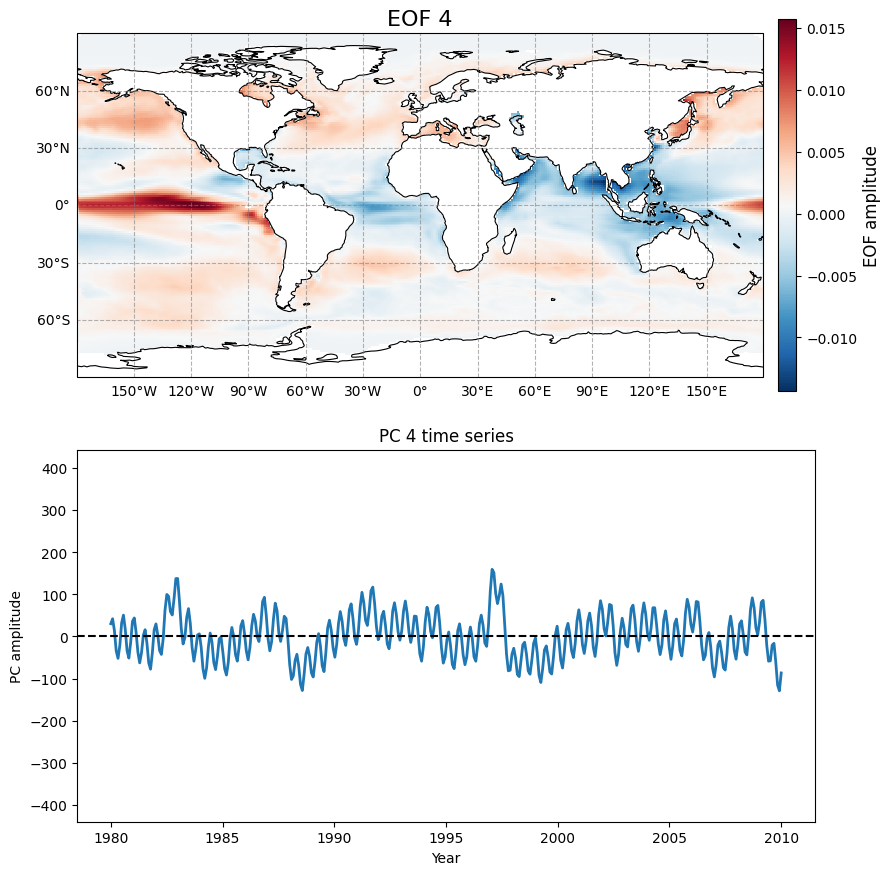

Plotting EOF 5...


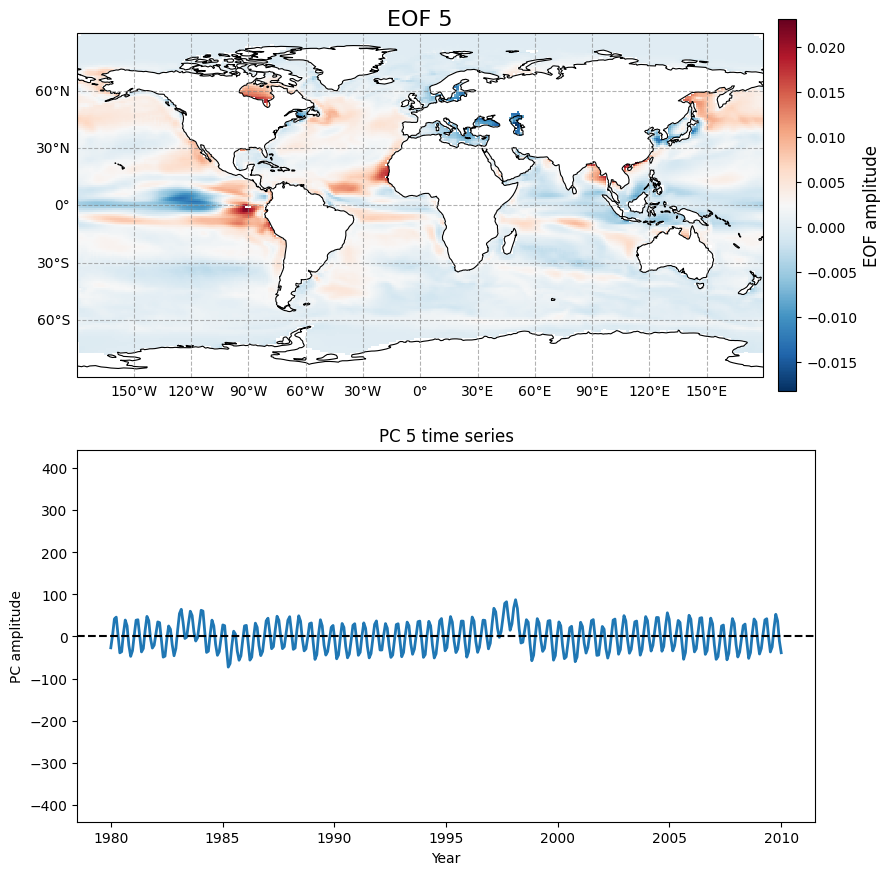

In [ ]:
import xarray as xr
import numpy as np
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# Charger grid et mask
grid = xr.open_dataset("/content/grid(5).nc")
lon = grid["plon"].values
lat = grid["plat"].values
pmask = grid["pmask"].values

# Grille régulière pour interpolation
lon_out = np.arange(-180, 181, 1)
lat_out = np.arange(-90, 91, 1)
lon_out_grid, lat_out_grid = np.meshgrid(lon_out, lat_out)

# Parallèles et méridiens
parallels = np.arange(-90, 91, 30)
meridians = np.arange(-180, 181, 30)

for i in range(5):

    print(f"Plotting EOF {i+1}...")

    # EOF masqué
    eof_map = eof1[i, :, :] * pmask
    points = np.column_stack((lon.flatten(), lat.flatten()))
    values = eof_map.flatten()

    eof_reg = griddata(points, values,
                       (lon_out_grid, lat_out_grid),
                       method='linear')

    valid = np.isfinite(eof_reg)
    vmin = eof_reg[valid].min()
    vmax = eof_reg[valid].max()

    # ---- Figure ----
    fig = plt.figure(figsize=(9,9))

    # Carte EOF
    ax1 = fig.add_subplot(211, projection=ccrs.PlateCarree())
    im = ax1.pcolormesh(
        lon_out_grid, lat_out_grid, eof_reg,
        cmap=plt.cm.RdBu_r,
        vmin=vmin, vmax=vmax,
        shading="auto",
        transform=ccrs.PlateCarree()
    )
    ax1.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax1.add_feature(cfeature.LAND, facecolor="white")

    # Parallèles et méridiens style Basemap
    gl = ax1.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.8,
        color="gray",
        alpha=0.6,
        linestyle="--"
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xlocator = plt.FixedLocator(meridians)
    gl.ylocator = plt.FixedLocator(parallels)
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}

    # Colorbar à droite
    cbar = fig.colorbar(im, ax=ax1, orientation='vertical', fraction=0.05, pad=0.02)
    cbar.set_label("EOF amplitude", fontsize=12)
    ax1.set_title(f"EOF {i+1}", fontsize=16)

    # Subplot PC
    ax2 = fig.add_subplot(212)
    days = np.linspace(year1, year2, pc1.shape[0])
    ax2.plot(days, pc1[:, i], linewidth=2)
    ax2.axhline(0, color='k', linestyle='--')
    ax2.set_xlabel("Year")
    ax2.set_ylabel("PC amplitude")
    ax2.set_title(f"PC {i+1} time series")
    ax2.set_ylim(np.min(pc1.squeeze()), np.max(pc1.squeeze()))

    plt.tight_layout()
    plt.show()


In [21]:
import glob
import xarray as xr
import numpy as np
from scipy.interpolate import griddata

all_files = sorted(glob.glob("/content/drive/MyDrive/ODA_OCN/ocn/ODA_ens.micom.hm.*.nc"))
files = [f for f in all_files if int(f.split('.')[-2].replace('-', '')) <= 201012]

ds_all = xr.open_mfdataset(
    files,
    combine="by_coords",
    engine="netcdf4",
    chunks={"time": 1}   # IMPORTANT pour la mémoire
)

sst = ds_all["sst"]   # (time, y, x)
print(sst.shape)


(84, 384, 320)


/tmp/ipython-input-1656190742.py:9: FutureWarning: In a future version of xarray the default value for data_vars will change from data_vars='all' to data_vars=None. This is likely to lead to different results when multiple datasets have matching variables with overlapping values. To opt in to new defaults and get rid of these warnings now use `set_options(use_new_combine_kwarg_defaults=True) or set data_vars explicitly.
  ds_all = xr.open_mfdataset(


In [23]:
sst_data = sst.values
nt,nlat,nlon = sst.shape
startY = year1
endY   = year2
ndy    = year2-year1+1
ny = nt/ndy

In [22]:
# Extract the time values (cftime objects)
time_vals = ds_all['time'].values

# Get min and max years
year1 = min(t.year for t in time_vals)
year2 = max(t.year for t in time_vals)

print("Year range:", year1, "-", year2)

Year range: 2000 - 2006


In [24]:
import numpy as np
import numpy.polynomial.polynomial as poly

# Dimensions
nt, nlat, nlon = sst_data.shape

sst_detrend = np.empty(sst_data.shape)
sst_coeffs  = np.empty((2, nlat, nlon))
sst_detrend[:,:,:] = np.nan

x = np.linspace(1, nt, nt)

for i in range(nlat):
    for j in range(nlon):
        y = sst_data[:, i, j]   # <-- use raw numpy array
        if np.all(np.isnan(y)):
            continue
        b = ~np.isnan(y)
        coefs = poly.polyfit(x[b], y[b], 1)
        sst_coeffs[0, i, j] = coefs[0]
        sst_coeffs[1, i, j] = coefs[1]
        ffit = poly.polyval(x[b], coefs)
        sst_detrend[b, i, j] = y[b] - ffit

In [25]:
sst_all = sst_detrend.reshape((ndy,int(ny),nlat,nlon), order='F').transpose((1,0,2,3)) # year, 36, lat, lon
sst_season = np.mean(sst_all, axis=0)
sst_diff = sst_all - sst_season
#mask_4d = np.broadcast_to((pmask_trimmed==0), sst_all.shape)
#sst_diff = np.ma.masked_array(sst_diff, mask=mask_4d) # have to do this, or fill in zeros in sst_diff.
sst_final = sst_diff.transpose((1,0,2,3)).reshape((ndy*int(ny),nlat,nlon), order='F')

In [49]:
sst_final.shape

(84, 384, 320)

In [26]:
grid = xr.open_dataset("/content/grid.nc")

lon = grid["plon"].values
lat = grid["plat"].values
pmask = grid["pmask"].values


In [47]:
grid

<xarray.Dataset> Size: 67MB
Dimensions:  (y: 384, x: 320, nv: 4, pcomp: 86231, qcomp: 87976, ucomp: 88019,
              vcomp: 87567)
Coordinates:
  * pcomp    (pcomp) int32 345kB 641 642 643 849 ... 122511 122512 122513 122514
  * qcomp    (qcomp) int32 352kB 642 643 850 851 ... 122648 122832 122833 122834
  * ucomp    (ucomp) int32 352kB 641 642 643 644 ... 122512 122513 122514 122515
  * vcomp    (vcomp) int32 350kB 641 642 643 849 ... 122831 122832 122833 122834
Dimensions without coordinates: y, x, nv
Data variables: (12/53)
    insw     (y, x) int32 492kB ...
    jnsw     (y, x) int32 492kB ...
    ins      (y, x) int32 492kB ...
    jns      (y, x) int32 492kB ...
    inse     (y, x) int32 492kB ...
    jnse     (y, x) int32 492kB ...
    ...       ...
    vdepth   (y, x) float64 983kB ...
    pmask    (y, x) int32 492kB 0 0 0 0 0 0 0 0 0 0 0 ... 0 0 0 0 0 0 0 0 0 0 0
    umask    (y, x) int32 492kB ...
    vmask    (y, x) int32 492kB ...
    qmask    (y, x) int32 492kB ...
    cplmask  (y, x) int32 492kB ...
Attributes:
    nreg:     1

In [34]:
lon_out = np.arange(-180, 181, 1)
lat_out = np.arange(-90, 91, 1)
lon_out_grid, lat_out_grid = np.meshgrid(lon_out, lat_out)

points = np.column_stack((lon.flatten(), lat.flatten()))
pmask_reg = griddata(
    points,
    pmask.flatten(),
    (lon_out_grid, lat_out_grid),
    method="nearest"   # IMPORTANT pour un masque
)

pmask_reg = np.where(pmask_reg >= 0.5, 1, 0)

In [39]:
def interp_2d(field_2d):
    values = field_2d.flatten()
    field_reg = griddata(
        points, values,
        (lon_out_grid, lat_out_grid),
        method="linear"
    )
    return field_reg




In [40]:
ntime = sst_final.shape[0]
sst_interp_list = []

for t in range(sst_final.shape[0]):
    print(f"Interpolating time step {t+1}/{sst_final.shape[0]}")

    field = sst_final[t, :, :]

    # Interpolation
    field_reg = interp_2d(field)

    # --- APPLIQUER LE MASQUE ICI ---
    field_reg[pmask_reg == 0] = np.nan

    sst_interp_list.append(field_reg)



Interpolating time step 1/84
Interpolating time step 2/84
Interpolating time step 3/84
Interpolating time step 4/84
Interpolating time step 5/84
Interpolating time step 6/84
Interpolating time step 7/84
Interpolating time step 8/84
Interpolating time step 9/84
Interpolating time step 10/84
Interpolating time step 11/84
Interpolating time step 12/84
Interpolating time step 13/84
Interpolating time step 14/84
Interpolating time step 15/84
Interpolating time step 16/84
Interpolating time step 17/84
Interpolating time step 18/84
Interpolating time step 19/84
Interpolating time step 20/84
Interpolating time step 21/84
Interpolating time step 22/84
Interpolating time step 23/84
Interpolating time step 24/84
Interpolating time step 25/84
Interpolating time step 26/84
Interpolating time step 27/84
Interpolating time step 28/84
Interpolating time step 29/84
Interpolating time step 30/84
Interpolating time step 31/84
Interpolating time step 32/84
Interpolating time step 33/84
Interpolating time 

In [41]:
sst_interp = xr.DataArray(
    data=np.array(sst_interp_list),
    dims=("time", "lat", "lon"),
    coords={
        "time": np.arange(ntime),
        "lat": lat_out,
        "lon": lon_out
    },
    name="sst_anom"
)

print(sst_interp)


<xarray.DataArray 'sst_anom' (time: 84, lat: 181, lon: 361)> Size: 44MB
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan, -0.0177827 , -0.01776651, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         n

In [6]:
sst_interp = xr.DataArray(
    data=np.array(sst_interp_list),
    dims=("time", "lat", "lon"),
    coords={
        "time": sst.time.values,
        "lat": lat_out,
        "lon": lon_out
    },
    name="sst"
)

print(sst_interp)


<xarray.DataArray 'sst' (time: 83, lat: 181, lon: 361)> Size: 43MB
array([[[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        ...,
        [        nan, -1.79759671, -1.79761523, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan]],

       [[        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],
        [        nan,         nan,         nan, ...,         nan,
                 nan,         nan],


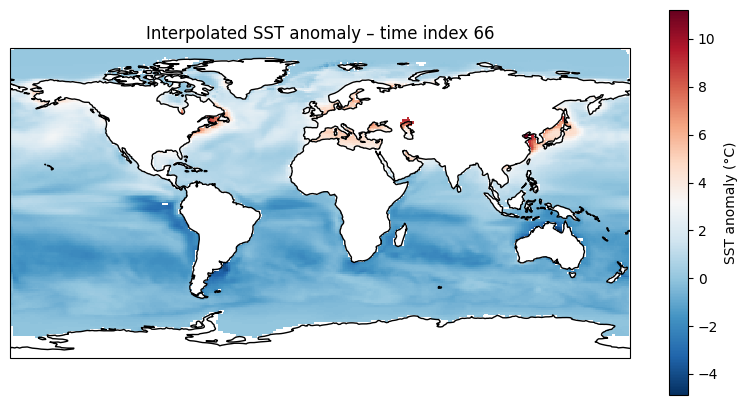

In [42]:
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

t0 = np.random.randint(0, ntime)

fig = plt.figure(figsize=(10,5))
ax = plt.axes(projection=ccrs.PlateCarree())

im = ax.pcolormesh(
    lon_out, lat_out, sst_interp[t0],
    shading="auto", cmap="RdBu_r",
    transform=ccrs.PlateCarree()
)

ax.add_feature(cfeature.COASTLINE)
ax.add_feature(cfeature.LAND, facecolor="white")
ax.set_global()
plt.colorbar(im, ax=ax, label="SST anomaly (°C)")
plt.title(f"Interpolated SST anomaly – time index {t0}")
plt.show()


In [50]:
lat = lat_out  # de la grille interpolée
coslat = np.cos(np.deg2rad(lat))
wgts = np.sqrt(coslat)[:, np.newaxis]


In [52]:
from eofs.xarray import Eof

solver = Eof(sst_interp, weights=wgts)
eof1 = solver.eofs(neofs=10)
pc1  = solver.pcs(npcs=10, pcscaling=0)
varfrac = solver.varianceFraction()
lambdas = solver.eigenvalues()




Plotting EOF 1...


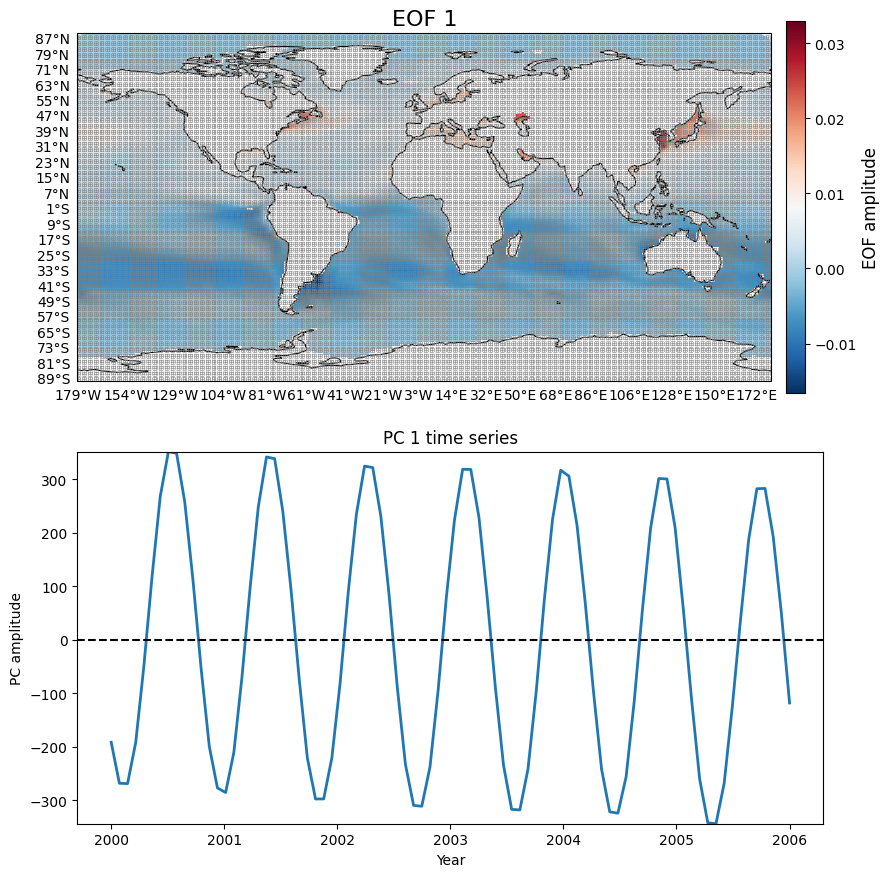

Plotting EOF 2...


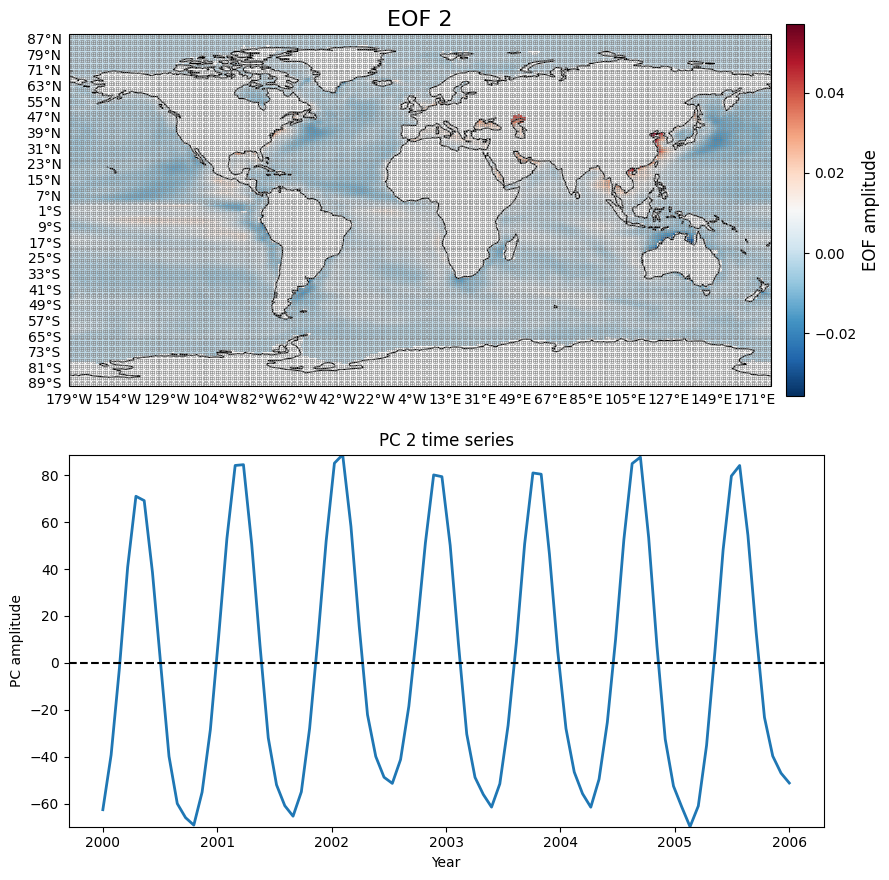

Plotting EOF 3...


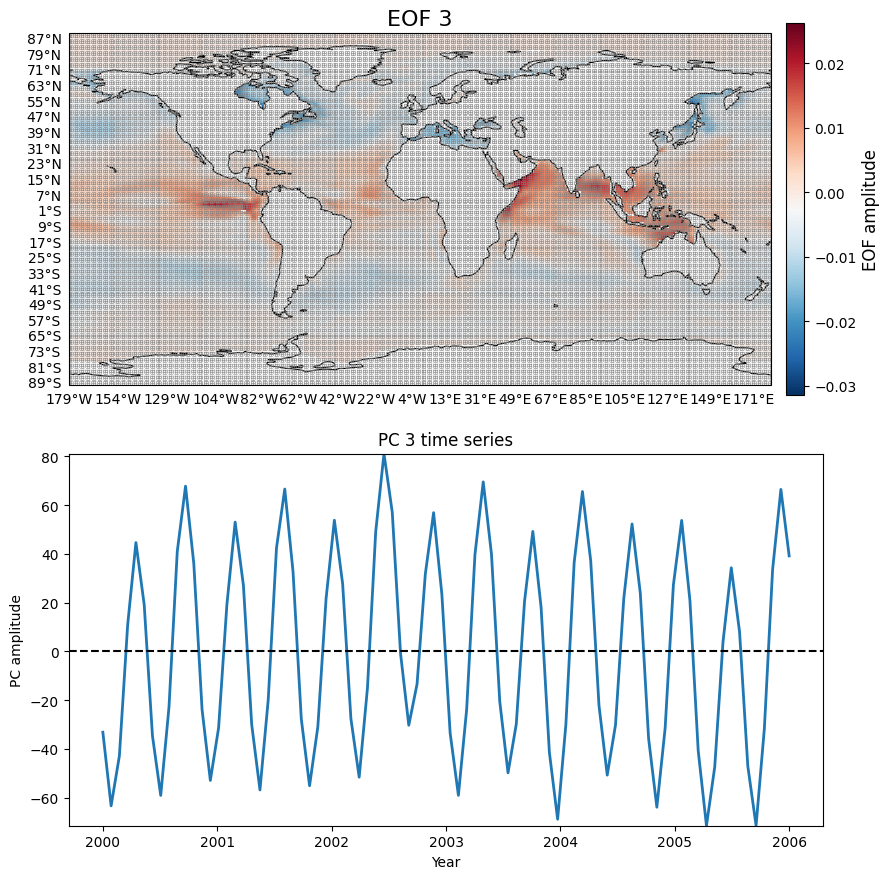

Plotting EOF 4...


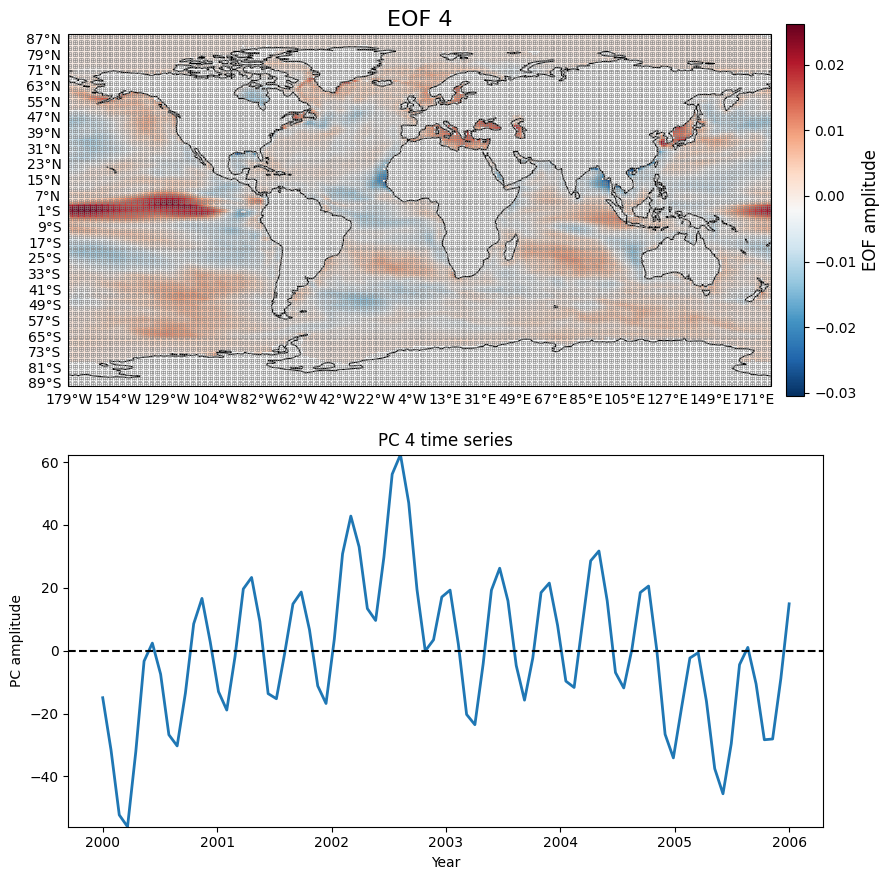

Plotting EOF 5...


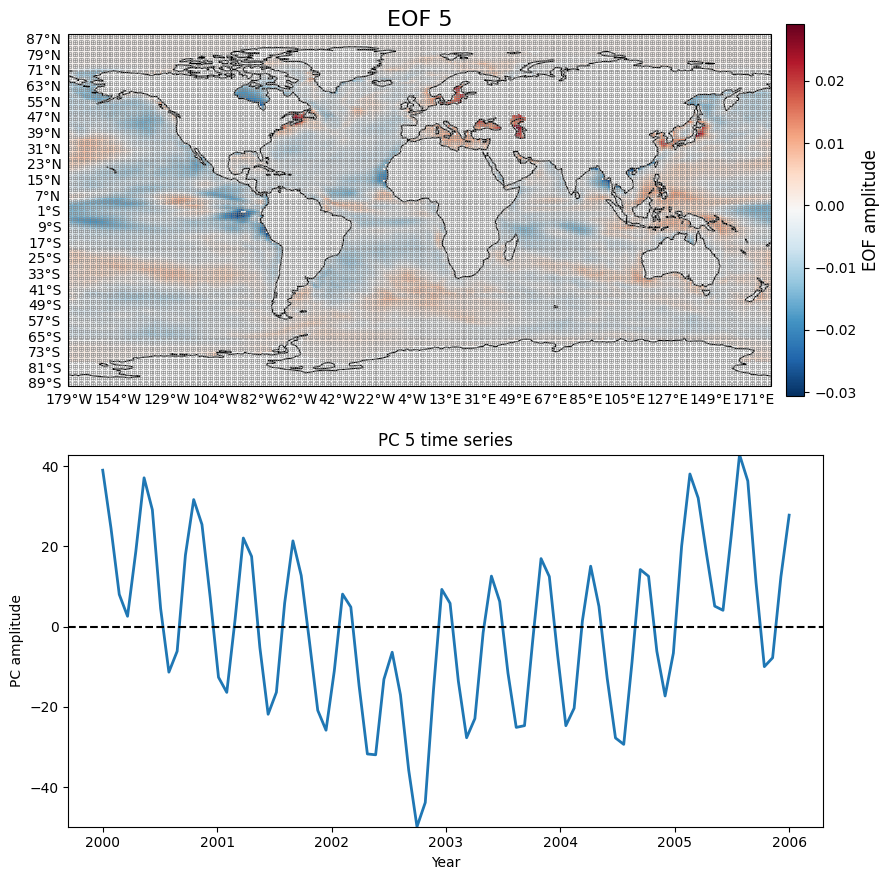

In [55]:
import xarray as xr
import numpy as np
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from cartopy.mpl.ticker import LongitudeFormatter, LatitudeFormatter

# Parallèles et méridiens
parallels = lat_out
meridians = lon_out

for i in range(5):
    print(f"Plotting EOF {i+1}...")

    # EOF déjà sur la grille régulière
    eof_map = eof1[i, :, :]  # shape = (lat_out, lon_out)

    vmin = np.nanmin(eof_map)
    vmax = np.nanmax(eof_map)

    # ---- Figure ----
    fig = plt.figure(figsize=(9,9))

    # Carte EOF
    ax1 = fig.add_subplot(211, projection=ccrs.PlateCarree())
    im = ax1.pcolormesh(
        lon_out_grid, lat_out_grid, eof_map,
        cmap=plt.cm.RdBu_r,
        vmin=vmin, vmax=vmax,
        shading="auto",
        transform=ccrs.PlateCarree()
    )
    ax1.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax1.add_feature(cfeature.LAND, facecolor="white")

    # Parallèles et méridiens
    gl = ax1.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=0.8,
        color="gray",
        alpha=0.6,
        linestyle="--"
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xlocator = plt.FixedLocator(meridians)
    gl.ylocator = plt.FixedLocator(parallels)
    gl.xlabel_style = {'size': 10}
    gl.ylabel_style = {'size': 10}

    # Colorbar
    cbar = fig.colorbar(im, ax=ax1, orientation='vertical', fraction=0.05, pad=0.02)
    cbar.set_label("EOF amplitude", fontsize=12)
    ax1.set_title(f"EOF {i+1}", fontsize=16)

    # Subplot PC
    ax2 = fig.add_subplot(212)
    days = np.linspace(year1, year2, pc1.shape[0])
    ax2.plot(days, pc1[:, i], linewidth=2)
    ax2.axhline(0, color='k', linestyle='--')
    ax2.set_xlabel("Year")
    ax2.set_ylabel("PC amplitude")
    ax2.set_title(f"PC {i+1} time series")
    ax2.set_ylim(np.nanmin(pc1[:, i]), np.nanmax(pc1[:, i]))

    plt.tight_layout()
    plt.show()
